## In-Class Guided Exercise:
:

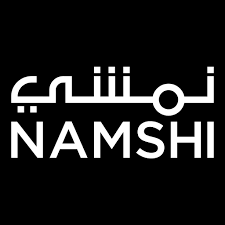

Let us web scrape Namshi site

### Import needed libraries


In [189]:
import requests
import httpx  # if you want to use httpx instead of requests

import pandas as pd
from bs4 import BeautifulSoup
from time import sleep



### Steps on using BeautifulSoup:
#### 1. Use `requests` to access the url of the web page you want to scrape

In [190]:
url='https://www.namshi.com/bahrain-en/kids-shoes-boys/?page=1'


In [191]:
# html_page = requests.get(url)


# if you get error or run forever, then:
# 1. Stop or kill the kernel
# 2. comment the above line
# 3. uncomment the below two lines 
# 4. run everything from the begining including this cell 

hdr={"user-agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 YaBrowser/23.3.0.1922 (beta) Yowser/2.5 Safari/537.3-449"}
html_page = requests.get(url,headers=hdr)



In [192]:
# check the status code if it is 200 then everthing is OK
html_page.status_code
# 200 mean OK 

200

#### 2. Now that we have the web page, we can parse it with beautifulsoup:

In [193]:
soup = BeautifulSoup(html_page.text, 'html.parser')



- Get the title of the page using the tag 'title':

In [194]:

soup.title.text


"Boys' Shoes Bahrain | Best Price Offers | Manama, Riffa"

#### 3. Get all the items in that page
- Use `inspect` on the web page to know how to collect the items 
- Create a variable that contains all the items in that web page


In [195]:
namshi = soup.find_all("div",class_="ProductBox_container__wiajf ProductBox_boxContainer__p7PaQ")

In [196]:
# check one of the items collected
namshi[0]

<div class="ProductBox_container__wiajf ProductBox_boxContainer__p7PaQ"><a class="ProductBox_container__wiajf" href="/bahrain-en/buy-new-balance-youth-530/V24336DE3CE7197ABB195V/p/"><div class="ProductBox_imageContainer__qrIJP"><div><section><div class="EmblaCarousel_outerWrapper__wzwd8"><div class="EmblaCarousel_wrapper__ndTTF"><div class="EmblaCarousel_container__MkuxD"><div class="EmblaCarousel_carouselContainer__C7YLK"><div class="EmblaCarousel_slidesContainer__NYcld"><div style="flex:0 0 calc(100%)"><div class="ProductImage_imageContainer__B5pcR"><img alt="New Balance Youth 530" class="ProductImage_image__Gv0_w ProductImage_outlined__NEzjp" data-nimg="1" decoding="async" fetchpriority="high" height="1091" loading="eager" src="https://f.nooncdn.com/p/pzsku/Z1C6FA7FDAD0A7FE69F6AZ/45/_/1775111234/109b4a05-97ee-4352-8a2e-e2c08c39bb8f.jpg?format=webp&amp;width=800" style="color:transparent;background-image:url(https://f.nooncdn.com/s/app/2025/nm-namshi-frontend/f81167559b030e2eff35e904

#### 4. Using one item, try to collect the information that you want to scrape
- In our web page here, we want to collect the following:
    - Product Title
    - Brand
    - Price
    - Currency
    - PreReduction Price
    - Discount



##### 4.1 *Get the Product Title*

In [197]:
namshi[0].find("div",class_="ProductBox_productTitle__6tQ3b").text

'Youth 530'

##### 4.2 *Get the Brand*

In [198]:

namshi[0].find("div", class_="OutletAndBrand_brandAndOutletTag__eEj4l").text


'New Balance'

##### 4.3 *Get the Price*

In [199]:
namshi[0].find("span", class_="ProductPrice_value__YcE7Z").text



'52.25'

##### 4.4 *Get the Currency*

In [200]:
namshi[0].find("span", class_="ProductPrice_currency__zHaox").text



'BHD'

##### 4.5 *Get the PreReduction Price*

In [201]:
namshi[2].find("div", class_="ProductPrice_preReductionPrice__oM4c9").text


'21.57'

##### 4.6 *Get the Discount*

In [202]:

namshi[9].find("span", class_="DiscountTag_value__SofQj").text



'-21%'

#### 5. Collect all the information of all the items using `loops`
- Now, once we know how to get in information we want from one item, we can now collect all the information from all the items using `for loop`
- First of all, we need to create a list for each info we want to collect and append the scraped info to those lists

In [203]:
# define empty lists for your collections
titles = []
brands = []
prices = []
currencies = []
prereduction_prices = []
discounts = []

# your code here
for item in namshi:
    try:
        title = item.find("div", class_="ProductBox_productTitle__6tQ3b")
        titles.append(title.text)
    except AttributeError:
        titles.append(None)

    try:
        brand = item.find("div", class_="OutletAndBrand_brandAndOutletTag__eEj4l")
        brands.append(brand.text)
    except AttributeError:
        brands.append(None)

    try:
        price = item.find("span", class_="ProductPrice_value__YcE7Z")
        prices.append(price.text)
    except AttributeError:
        prices.append(None)

    try:
        currency = item.find("span", class_="ProductPrice_currency__zHaox")
        currencies.append(currency.text)
    except AttributeError:
        currencies.append(None)

    try:
        prereduction = item.find("div", class_="ProductPrice_preReductionPrice__oM4c9")
        prereduction_prices.append(prereduction.text)
    except AttributeError:
        prereduction_prices.append(None)

    try:
        discount = item.find("span", class_="DiscountTag_value__SofQj")
        discounts.append(discount.text)
    except AttributeError:
        discounts.append(None)

In [204]:
# check what one of the lists contains
discount

<span class="DiscountTag_value__SofQj" dir="ltr">-<!-- -->18<!-- -->%</span>

#### 6. Modify the previous `loop` to collect multiple web pages 
- In below code, we collect the web pages from 1 to 5 of that site
- Notice that the only difference from page to page is the page number which we can use in the `for loop` with the formatted text f"

In [205]:
# define empty lists for your collections
titles = []
brands = []
prices = []
currencies = []
prereduction_prices = []
discounts = []

# your code here
hdr = {"user-agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 YaBrowser/23.3.0.1922 (beta) Yowser/2.5 Safari/537.3-449"}

for page in range(1, 6):
    url = f'https://www.namshi.com/bahrain-en/kids-shoes-boys/?page={page}'
    html_page = requests.get(url, headers=hdr)
    soup = BeautifulSoup(html_page.text, 'html.parser')
    namshi = soup.find_all("div", class_="ProductBox_container__wiajf ProductBox_boxContainer__p7PaQ")

    for item in namshi:
        try:
            title = item.find("div", class_="ProductBox_productTitle__6tQ3b")
            titles.append(title.text)
        except AttributeError:
            titles.append(None)

        try:
            brand = item.find("div", class_="OutletAndBrand_brandAndOutletTag__eEj4l")
            brands.append(brand.text)
        except AttributeError:
            brands.append(None)

        try:
            price = item.find("span", class_="ProductPrice_value__YcE7Z")
            prices.append(price.text)
        except AttributeError:
            prices.append(None)

        try:
            currency = item.find("span", class_="ProductPrice_currency__zHaox")
            currencies.append(currency.text)
        except AttributeError:
            currencies.append(None)

        try:
            prereduction = item.find("div", class_="ProductPrice_preReductionPrice__oM4c9")
            prereduction_prices.append(prereduction.text)
        except AttributeError:
            prereduction_prices.append(None)

        try:
            discount = item.find("span", class_="DiscountTag_value__SofQj")
            discounts.append(discount.text)
        except AttributeError:
            discounts.append(None)

#### 7. Create a DataFrame to save all the scraped info. into a table.


In [206]:
namshi_df= pd.DataFrame({
    "Title": titles,
    "Brand": brands,
    "Price": prices,
    "Currency": currencies,
    "PreReduction_Price": prereduction_prices,
    "Discount": discounts
})



In [207]:
# display your dataframe
namshi_df.head(20)

,Title,Brand,Price,Currency,PreReduction_Price,Discount
0,Youth 530,New Balance,52.25,BHD,NaN,NaN
1,Youth Runfalcon 5 El,Adidas,12.98,BHD,21.57,-40%
2,Kids Tensaur Comfort Ac,Adidas,16.39,BHD,21.57,-25%
3,NIKE V5 RNR E BP,Nike,38.59,BHD,NaN,NaN
4,Air Jordan 1 Mid,Jordan,40.52,BHD,57.35,-30%
5,Youth Gel-Nyc Gs,asics,49.51,BHD,52.36,-6%
6,Youth Handball Spezial,adidas Originals,35.4,BHD,46.50,-24%
7,Kids Handball Spezial,adidas Originals,20.38,BHD,30.24,-33%
8,Tensaur Comfort Shoes Kids,Adidas,23.79,BHD,NaN,NaN
9,Kids Tensaur Run 3.0 El,Adidas,15.48,BHD,19.41,-21%


#### 8. Save your dataframe to a `CSV` file
- Save the output to a csv file (excluding the index)

In [208]:
# Save the output to a csv file (excluding the index)
namshi_df.to_csv("namshi.csv", index=False)